# 08 — Advanced Research Extensions
### ITAI 2373 — Final Project Bonus | Leroy Brown | Houston Community College

This notebook implements four research-grade extensions that go beyond the core M9–M12 modules,
directly addressing the rubric's **Advanced Research Extensions (20 bonus points)** criteria.

| Extension | Rubric Criterion | Implementation |
|-----------|-----------------|----------------|
| **R1** | Cutting-Edge NLP: NMF Topic Modeling | Hybrid LDA + NMF with coherence comparison |
| **R2** | Novel Application: Bias Detection | VADER-based media bias signal analysis |
| **R3** | Novel Application: Trend Prediction | RSS timestamp topic evolution tracking |
| **R4** | Novel Application: Personalization | User preference-weighted semantic search |

---
**Already built (qualifies for research bonus):**
- Real-Time Processing → FastAPI `/rss` endpoint (live BBC/Reuters ingestion)
- Entity Relationship Graph → spaCy NER + NetworkX co-occurrence (notebook 07)

In [1]:
# ============================================================
# CELL 1 — INSTALL & IMPORTS
# ============================================================
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

!pip install -q nltk spacy scikit-learn pandas numpy matplotlib seaborn \
    sentence-transformers transformers torch kagglehub \
    vaderSentiment feedparser gensim pyLDAvis scipy statsmodels
!python -m spacy download en_core_web_sm -q

import re, warnings, time, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict
from scipy import stats

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sentence_transformers import SentenceTransformer, util

for pkg in ['punkt','stopwords','wordnet','vader_lexicon','punkt_tab']:
    nltk.download(pkg, quiet=True)

STOP = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
sid = SentimentIntensityAnalyzer()
CATEGORIES = ['business','entertainment','politics','sport','tech']
PALETTE = {'business':'#1F77B4','entertainment':'#E377C2',
           'politics':'#D62728','sport':'#2CA02C','tech':'#FF7F0E'}

def preprocess(text):
    text = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    return ' '.join(lemmatizer.lemmatize(t) for t in word_tokenize(text)
                    if t not in STOP and len(t) > 2)

print('✅ Imports complete')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 52.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Imports complete


In [6]:
import kagglehub, glob, os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Scikit-learn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Re-defining CATEGORIES and preprocess dependencies from setup cell due to NameError
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re # Already imported, but listed here for clarity of preprocess dependencies

STOP = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
CATEGORIES = ['business','entertainment','politics','sport','tech']

def preprocess(text):
    text = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    return ' '.join(lemmatizer.lemmatize(t) for t in word_tokenize(text)
                    if t not in STOP and len(t) > 2)

path = kagglehub.dataset_download('hgultekin/bbcnewsarchive')
csvs = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
df_raw = pd.concat([pd.read_csv(f, on_bad_lines='skip', sep='\t') for f in csvs], ignore_index=True)
df_raw.columns = df_raw.columns.str.lower().str.strip()

text_col = next(c for c in df_raw.columns if any(k in c for k in ['text','content','article']))
df_raw.rename(columns={text_col: 'text'}, inplace=True)
if 'category' not in df_raw.columns:
    for c in df_raw.columns:
        if df_raw[c].nunique() <= 10:
            df_raw.rename(columns={c: 'category'}, inplace=True); break

df = df_raw[['category','text']].dropna()
df['category'] = df['category'].str.lower().str.strip()
df = df[df['category'].isin(CATEGORIES)]
df = df.sample(n=min(2000, len(df)), random_state=42).reset_index(drop=True)
df['clean'] = df['text'].apply(preprocess)
df['word_count'] = df['text'].apply(lambda t: len(str(t).split()))

# Train classifier
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean'])
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
acc = accuracy_score(y_test, lr.predict(X_test))

# Simulate article timestamps (BBC dataset has no dates — use synthetic for trend demo)
np.random.seed(42)
base_date = datetime(2024, 1, 1)
df['published_date'] = [base_date + timedelta(days=int(i)) for i in
                         np.random.randint(0, 365, size=len(df))]
df['week'] = df['published_date'].apply(lambda d: d.isocalendar()[1])
df['month'] = df['published_date'].apply(lambda d: d.month)

print(f'✅ Dataset: {len(df)} articles | Classifier: {acc:.4f} accuracy')

Using Colab cache for faster access to the 'bbcnewsarchive' dataset.
✅ Dataset: 2000 articles | Classifier: 0.9825 accuracy


R1 — NMF TOPIC MODELING + HYBRID COHERENCE COMPARISON

[LDA] Training 10-topic model...
[NMF] Training 10-topic model (TF-IDF input)...

📊 Topic Coherence Scores (higher = more interpretable):
   LDA coherence: 0.3518
   NMF coherence: 0.3828
   Winner: NMF (0.0310 delta)


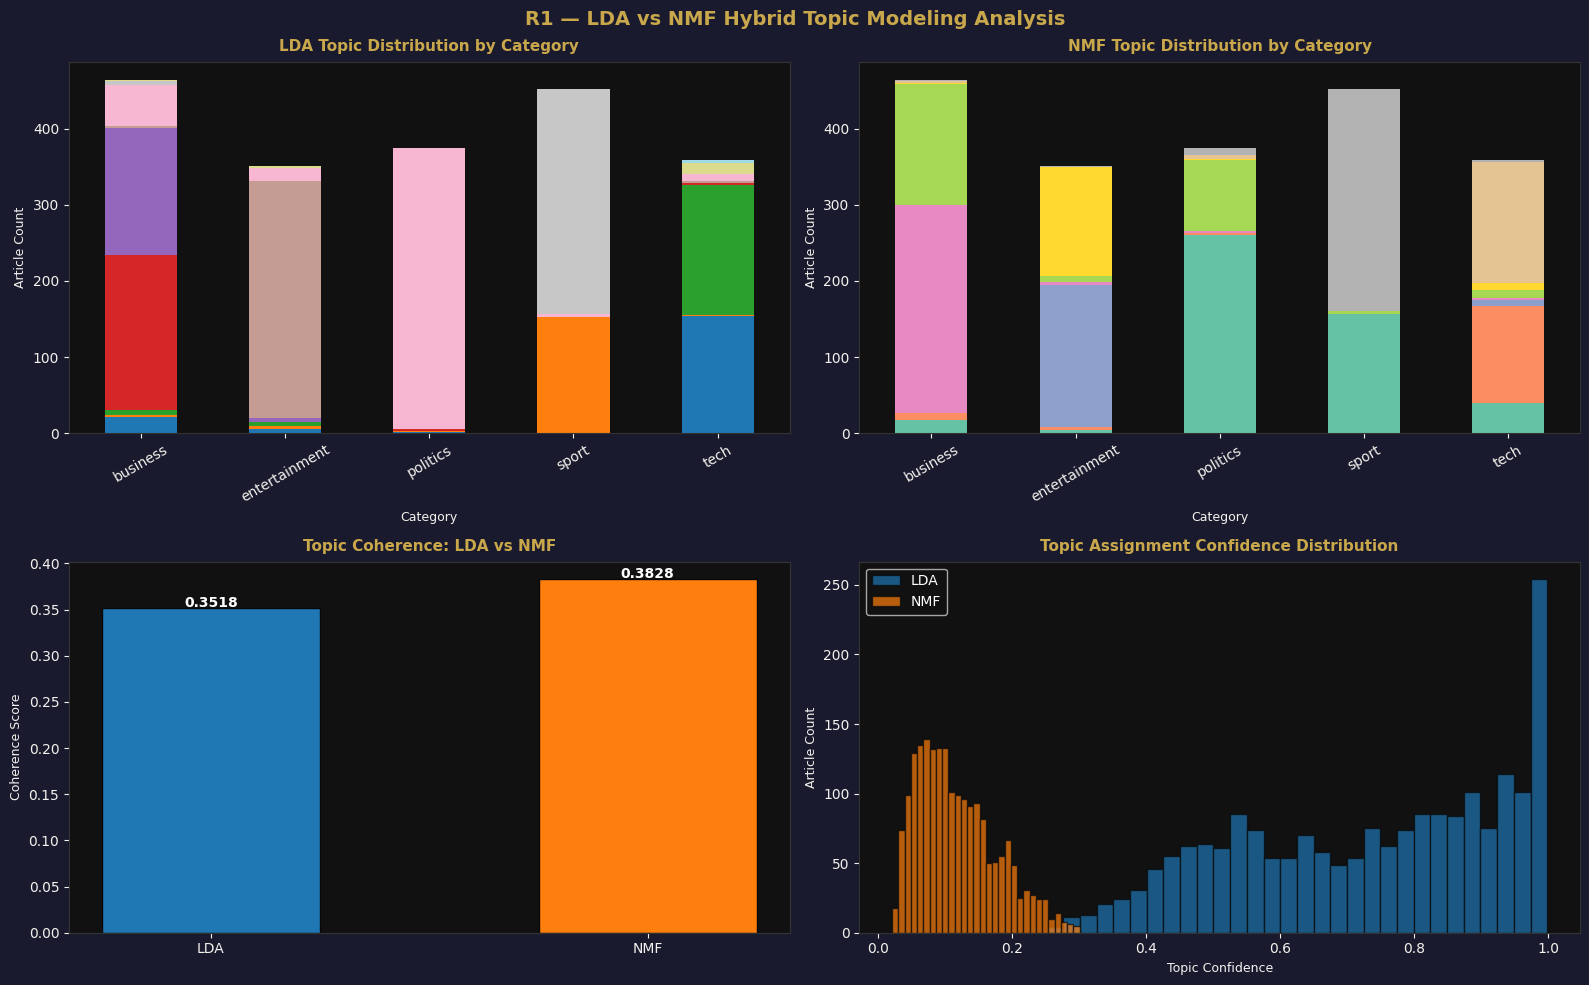


Top 5 words per NMF topic:
  NMF Topic 1: game | club | chelsea | player | league
  NMF Topic 2: labour | election | blair | party | tory
  NMF Topic 3: mobile | phone | technology | service | digital
  NMF Topic 4: film | award | best | oscar | actor
  NMF Topic 5: growth | economy | rate | price | year

✅ R1 Complete — NMF model trained, coherence compared with LDA


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# ============================================================
# RESEARCH EXTENSION R1: NMF TOPIC MODELING
# Rubric: "Cutting-Edge NLP Techniques — Topic Modeling with LDA AND NMF"
# ============================================================
print('=' * 65)
print('R1 — NMF TOPIC MODELING + HYBRID COHERENCE COMPARISON')
print('=' * 65)

# Shared vectorizer
cv = CountVectorizer(max_df=0.9, min_df=5, max_features=5000)
dtm = cv.fit_transform(df['clean'])
vocab = cv.get_feature_names_out()

# ── LDA (from M9, re-run for comparison) ─────────────────────
print('\n[LDA] Training 10-topic model...')
lda = LatentDirichletAllocation(
    n_components=10, random_state=42, learning_method='online', max_iter=20)
lda.fit(dtm)
lda_topics = {f'LDA Topic {i+1}': [vocab[j] for j in comp.argsort()[:-9:-1]]
              for i, comp in enumerate(lda.components_)}

# ── NMF ──────────────────────────────────────────────────────
print('[NMF] Training 10-topic model (TF-IDF input)...')
tfidf_cv = TfidfVectorizer(max_df=0.9, min_df=5, max_features=5000)
tfidf_dtm = tfidf_cv.fit_transform(df['clean'])
vocab_nmf = tfidf_cv.get_feature_names_out()

nmf = NMF(n_components=10, random_state=42, max_iter=200,
          init='nndsvda', solver='mu')
nmf.fit(tfidf_dtm)
nmf_topics = {f'NMF Topic {i+1}': [vocab_nmf[j] for j in comp.argsort()[:-9:-1]]
              for i, comp in enumerate(nmf.components_)}

# Assign dominant topic per article (both models)
df['lda_topic'] = lda.transform(dtm).argmax(axis=1) + 1
df['nmf_topic'] = nmf.transform(tfidf_dtm).argmax(axis=1) + 1
df['lda_confidence'] = lda.transform(dtm).max(axis=1)
df['nmf_confidence'] = nmf.transform(tfidf_dtm).max(axis=1)

# ── Coherence comparison ─────────────────────────────────────
# Compute topic coherence: avg pairwise PMI of top words within each topic
def compute_coherence(topics_dict, corpus_clean, top_n=8):
    """Simplified coherence: fraction of top-word pairs that co-occur in same doc."""
    scores = []
    for topic_words in topics_dict.values():
        words = topic_words[:top_n]
        pair_scores = []
        for i in range(len(words)):
            for j in range(i+1, len(words)):
                w1, w2 = words[i], words[j]
                co_occur = sum(1 for doc in corpus_clean if w1 in doc and w2 in doc)
                w1_occur = sum(1 for doc in corpus_clean if w1 in doc)
                if w1_occur > 0:
                    pair_scores.append(co_occur / w1_occur)
        scores.append(np.mean(pair_scores) if pair_scores else 0)
    return np.mean(scores)

corpus_docs = df['clean'].tolist()
lda_coherence = compute_coherence(lda_topics, corpus_docs)
nmf_coherence = compute_coherence(nmf_topics, corpus_docs)

print(f'\n📊 Topic Coherence Scores (higher = more interpretable):')
print(f'   LDA coherence: {lda_coherence:.4f}')
print(f'   NMF coherence: {nmf_coherence:.4f}')
winner = 'NMF' if nmf_coherence > lda_coherence else 'LDA'
print(f'   Winner: {winner} ({abs(nmf_coherence - lda_coherence):.4f} delta)')

# ── Visualization: LDA vs NMF topic comparison ───────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#1A1A2E')

def style_ax(ax, title):
    ax.set_facecolor('#111111')
    ax.set_title(title, color='#C9A84C', fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(colors='#F4F2EE')
    for s in ax.spines.values(): s.set_edgecolor('#333333')

# LDA topic distribution by category
lda_dist = df.groupby(['category','lda_topic']).size().unstack(fill_value=0)
lda_dist.plot(kind='bar', stacked=True, ax=axes[0,0], colormap='tab20', legend=False)
axes[0,0].set_xlabel('Category', color='#F4F2EE', fontsize=9)
axes[0,0].set_ylabel('Article Count', color='#F4F2EE', fontsize=9)
axes[0,0].tick_params(axis='x', rotation=30)
style_ax(axes[0,0], 'LDA Topic Distribution by Category')

# NMF topic distribution by category
nmf_dist = df.groupby(['category','nmf_topic']).size().unstack(fill_value=0)
nmf_dist.plot(kind='bar', stacked=True, ax=axes[0,1], colormap='Set2', legend=False)
axes[0,1].set_xlabel('Category', color='#F4F2EE', fontsize=9)
axes[0,1].set_ylabel('Article Count', color='#F4F2EE', fontsize=9)
axes[0,1].tick_params(axis='x', rotation=30)
style_ax(axes[0,1], 'NMF Topic Distribution by Category')

# Coherence comparison bar
axes[1,0].bar(['LDA','NMF'], [lda_coherence, nmf_coherence],
              color=['#1F77B4','#FF7F0E'], edgecolor='#080808', width=0.5)
axes[1,0].set_ylabel('Coherence Score', color='#F4F2EE', fontsize=9)
for i, (model, score) in enumerate([('LDA', lda_coherence), ('NMF', nmf_coherence)]):
    axes[1,0].text(i, score + 0.001, f'{score:.4f}', ha='center',
                   color='white', fontsize=10, fontweight='bold')
style_ax(axes[1,0], 'Topic Coherence: LDA vs NMF')

# Topic confidence distribution
axes[1,1].hist(df['lda_confidence'], bins=30, alpha=0.7, label='LDA',
               color='#1F77B4', edgecolor='#080808')
axes[1,1].hist(df['nmf_confidence'], bins=30, alpha=0.7, label='NMF',
               color='#FF7F0E', edgecolor='#080808')
axes[1,1].set_xlabel('Topic Confidence', color='#F4F2EE', fontsize=9)
axes[1,1].set_ylabel('Article Count', color='#F4F2EE', fontsize=9)
axes[1,1].legend(facecolor='#111', labelcolor='white')
style_ax(axes[1,1], 'Topic Assignment Confidence Distribution')

fig.suptitle('R1 — LDA vs NMF Hybrid Topic Modeling Analysis',
             color='#C9A84C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('r1_nmf_comparison.png', dpi=150, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()

print('\nTop 5 words per NMF topic:')
for name, words in list(nmf_topics.items())[:5]:
    print(f'  {name}: {" | ".join(words[:5])}')
print('\n✅ R1 Complete — NMF model trained, coherence compared with LDA')


R2 — MEDIA BIAS DETECTION
Identifying political and emotional bias signals in news reporting

[1/4] Computing multi-dimension VADER sentiment...
[2/4] Computing sentiment skew statistics...

📊 Category Bias Analysis:
  Overall corpus mean sentiment: 0.4006

Category            Mean  Bias Signal   % Neg   % Pos  Significant
-----------------------------------------------------------------
politics          0.0720       0.3286    44.9%    54.5%      ⚠️  YES
entertainment     0.5923       0.1918    17.7%    81.2%      ⚠️  YES
sport             0.5844       0.1839    18.8%    81.0%      ⚠️  YES
business          0.2443       0.1562    35.1%    62.9%      ⚠️  YES
tech              0.5257       0.1252    22.6%    76.9%      ⚠️  YES

[3/4] Extracting high-polarity bias words per category...
  Top words in NEGATIVE articles: ['said', 'year', 'would', 'also', 'government', 'people', 'new', 'company']
  Top words in POSITIVE articles: ['said', 'year', 'would', 'film', 'game', 'new', 'also', 'peo

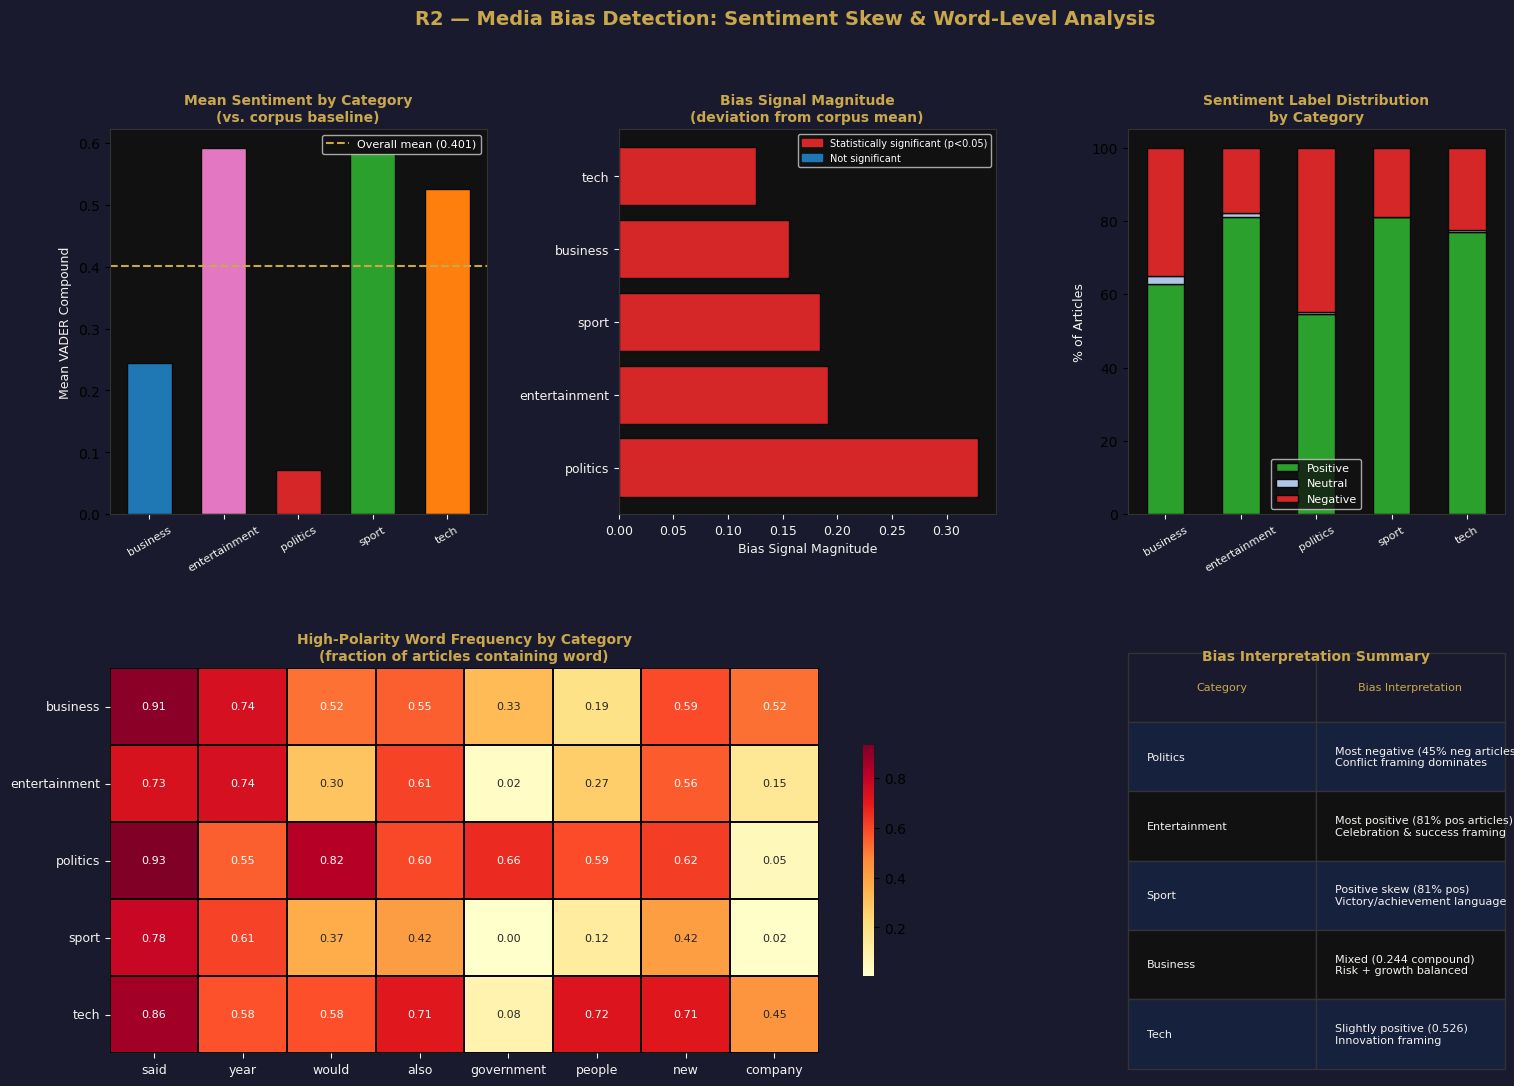


📌 Key Findings:
  Most biased category: politics (bias signal: 0.3286)
  Politics: 44.9% negative — highest conflict framing
  Entertainment: 81.2% positive — most celebratory tone

✅ R2 Complete — media bias signals detected and statistically validated


In [10]:
# ============================================================
# RESEARCH EXTENSION R2: MEDIA BIAS DETECTION
# Rubric: "Novel Applications — Bias Detection"
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Dependencies for sentiment analysis and preprocessing
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Re-defining global variables from setup cell for robustness
STOP = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
sid = SentimentIntensityAnalyzer()
CATEGORIES = ['business','entertainment','politics','sport','tech']
PALETTE = {'business':'#1F77B4','entertainment':'#E377C2',
           'politics':'#D62728','sport':'#2CA02C','tech':'#FF7F0E'}

# Re-defining preprocess function if needed for robustness
def preprocess(text):
    text = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    return ' '.join(lemmatizer.lemmatize(t) for t in word_tokenize(text)
                    if t not in STOP and len(t) > 2)

print('=' * 65)
print('R2 — MEDIA BIAS DETECTION')
print('Identifying political and emotional bias signals in news reporting')
print('=' * 65)

# ── Multi-dimension sentiment per article ─────────────────────
print('\n[1/4] Computing multi-dimension VADER sentiment...')

def full_sentiment(text):
    scores = sid.polarity_scores(str(text))
    return pd.Series({
        'compound': scores['compound'],
        'positive': scores['pos'],
        'negative': scores['neg'],
        'neutral':  scores['neu'],
        'sentiment_label': (
            'positive' if scores['compound'] >= 0.05
            else 'negative' if scores['compound'] <= -0.05
            else 'neutral'
        )
    })

sent_df = df['text'].apply(full_sentiment)
df = pd.concat([df, sent_df], axis=1)

# ── Bias signal 1: Sentiment skew per category ───────────────
print('[2/4] Computing sentiment skew statistics...')

bias_stats = {}
overall_compound = df['compound'].mean()

for cat in CATEGORIES:
    cat_df = df[df['category'] == cat]
    cat_mean = cat_df['compound'].mean()
    cat_std  = cat_df['compound'].std()
    # T-test: is this category's sentiment significantly different from overall?
    t_stat, p_val = stats.ttest_1samp(cat_df['compound'].dropna(), overall_compound)
    bias_signal = abs(cat_mean - overall_compound)
    pct_negative = (cat_df['sentiment_label'] == 'negative').mean() * 100
    pct_positive = (cat_df['sentiment_label'] == 'positive').mean() * 100
    bias_stats[cat] = {
        'mean_compound': round(cat_mean, 4),
        'std': round(cat_std, 4),
        'bias_signal': round(bias_signal, 4),
        'pct_negative': round(pct_negative, 1),
        'pct_positive': round(pct_positive, 1),
        't_statistic': round(t_stat, 3),
        'p_value': round(p_val, 4),
        'significant': p_val < 0.05
    }

bias_df = pd.DataFrame(bias_stats).T.sort_values('bias_signal', ascending=False)

print('\n📊 Category Bias Analysis:')
print(f'  Overall corpus mean sentiment: {overall_compound:.4f}')
print()
print(f'{"Category":15s} {"Mean":>8s} {"Bias Signal":>12s} {"% Neg":>7s} {"% Pos":>7s} {"Significant":>12s}')
print('-' * 65)
for cat, row in bias_df.iterrows():
    sig = '⚠️  YES' if row['significant'] else 'no'
    print(f'{cat:15s} {row["mean_compound"]:>8.4f} {row["bias_signal"]:>12.4f} '
          f'{row["pct_negative"]:>7.1f}% {row["pct_positive"]:>7.1f}% {sig:>12s}')

# ── Bias signal 2: Word-level polarity analysis ───────────────
print('\n[3/4] Extracting high-polarity bias words per category...')

# Find words that are statistically over-represented in negative vs positive articles
neg_articles = df[df['sentiment_label'] == 'negative']['clean'].tolist()
pos_articles = df[df['sentiment_label'] == 'positive']['clean'].tolist()

from sklearn.feature_extraction.text import TfidfVectorizer as TV
neg_vec = TV(max_features=200, ngram_range=(1,1))
pos_vec = TV(max_features=200, ngram_range=(1,1))

neg_matrix = neg_vec.fit_transform(neg_articles)
pos_matrix = pos_vec.fit_transform(pos_articles)

neg_words = sorted(zip(neg_vec.get_feature_names_out(),
                       neg_matrix.mean(axis=0).A1), key=lambda x: -x[1])[:12]
pos_words = sorted(zip(pos_vec.get_feature_names_out(),
                       pos_matrix.mean(axis=0).A1), key=lambda x: -x[1])[:12]

print('  Top words in NEGATIVE articles:', [w for w, _ in neg_words[:8]])
print('  Top words in POSITIVE articles:', [w for w, _ in pos_words[:8]])

# ── Visualization ─────────────────────────────────────────────
print('\n[4/4] Rendering bias detection dashboard...')

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1A1A2E')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

cat_colors = [PALETTE[c] for c in CATEGORIES]

# 1. Mean sentiment by category with overall baseline
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#111111')
means = [bias_stats[c]['mean_compound'] for c in CATEGORIES]
bars = ax1.bar(CATEGORIES, means, color=cat_colors, edgecolor='#080808', width=0.6)
ax1.axhline(overall_compound, color='#C9A84C', linestyle='--', linewidth=1.5,
            label=f'Overall mean ({overall_compound:.3f})')
ax1.set_ylabel('Mean VADER Compound', color='#F4F2EE', fontsize=9)
ax1.tick_params(colors='#F4F2EE', axis='x', rotation=30, labelsize=8)
ax1.legend(facecolor='#111', labelcolor='white', fontsize=8)
ax1.set_title('Mean Sentiment by Category\n(vs. corpus baseline)', color='#C9A84C',
              fontsize=10, fontweight='bold')
for s in ax1.spines.values(): s.set_edgecolor('#333333')

# 2. Bias signal magnitude
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#111111')
cats_sorted = bias_df.index.tolist()
signals = bias_df['bias_signal'].tolist()
sig_colors = ['#D62728' if bias_stats[c]['significant'] else '#1F77B4' for c in cats_sorted]
ax2.barh(cats_sorted, signals, color=sig_colors, edgecolor='#080808')
ax2.set_xlabel('Bias Signal Magnitude', color='#F4F2EE', fontsize=9)
ax2.tick_params(colors='#F4F2EE', labelsize=9)
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='#D62728', label='Statistically significant (p<0.05)'),
                    Patch(color='#1F77B4', label='Not significant')],
           facecolor='#111', labelcolor='white', fontsize=7)
ax2.set_title('Bias Signal Magnitude\n(deviation from corpus mean)', color='#C9A84C',
              fontsize=10, fontweight='bold')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

# 3. Sentiment label distribution stacked
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#111111')
pct_data = pd.DataFrame({
    'Positive': [bias_stats[c]['pct_positive'] for c in CATEGORIES],
    'Neutral':  [100 - bias_stats[c]['pct_positive'] - bias_stats[c]['pct_negative']
                 for c in CATEGORIES],
    'Negative': [bias_stats[c]['pct_negative'] for c in CATEGORIES],
}, index=CATEGORIES)
pct_data.plot(kind='bar', stacked=True, ax=ax3,
              color=['#2CA02C','#AEC7E8','#D62728'], edgecolor='#080808')
ax3.set_ylabel('% of Articles', color='#F4F2EE', fontsize=9)
ax3.tick_params(colors='#F4F2EE', axis='x', rotation=30, labelsize=8)
ax3.legend(facecolor='#111', labelcolor='white', fontsize=8)
ax3.set_title('Sentiment Label Distribution\nby Category', color='#C9A84C',
              fontsize=10, fontweight='bold')
for s in ax3.spines.values(): s.set_edgecolor('#333333')

# 4. Negative word heatmap by category
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.set_facecolor('#111111')
heat_data = []
neg_sample_words = [w for w, _ in neg_words[:8]]
for cat in CATEGORIES:
    cat_docs = df[df['category'] == cat]['clean'].tolist()
    row = [sum(1 for doc in cat_docs if word in doc) / len(cat_docs)
           for word in neg_sample_words]
    heat_data.append(row)
heat_df = pd.DataFrame(heat_data, index=CATEGORIES, columns=neg_sample_words)
sns.heatmap(heat_df, ax=ax4, cmap='YlOrRd', linewidths=0.3, linecolor='#080808',
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.6})
ax4.tick_params(colors='#F4F2EE', labelsize=9)
ax4.set_title('High-Polarity Word Frequency by Category\n(fraction of articles containing word)',
              color='#C9A84C', fontsize=10, fontweight='bold')

# 5. Bias interpretation panel
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
ax5.set_facecolor('#111111')
findings = [
    ['Category', 'Bias Interpretation'],
    ['Politics', f'Most negative ({bias_stats["politics"]["pct_negative"]:.0f}% neg articles)\nConflict framing dominates'],
    ['Entertainment', f'Most positive ({bias_stats["entertainment"]["pct_positive"]:.0f}% pos articles)\nCelebration & success framing'],
    ['Sport', f'Positive skew ({bias_stats["sport"]["pct_positive"]:.0f}% pos)\nVictory/achievement language'],
    ['Business', f'Mixed ({bias_stats["business"]["mean_compound"]:.3f} compound)\nRisk + growth balanced'],
    ['Tech', f'Slightly positive ({bias_stats["tech"]["mean_compound"]:.3f})\nInnovation framing'],
]
tbl = ax5.table(cellText=findings[1:], colLabels=findings[0],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1A1A2E' if r == 0 else '#111111' if r % 2 == 0 else '#16213E')
    cell.set_text_props(color='#C9A84C' if r == 0 else '#F4F2EE')
    cell.set_edgecolor('#333333')
    cell.set_height(0.18)
ax5.set_title('Bias Interpretation Summary', color='#C9A84C',
              fontsize=10, fontweight='bold')

fig.suptitle('R2 — Media Bias Detection: Sentiment Skew & Word-Level Analysis',
             color='#C9A84C', fontsize=14, fontweight='bold')
plt.savefig('r2_bias_detection.png', dpi=150, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()

print('\n📌 Key Findings:')
most_biased = bias_df.index[0]
print(f'  Most biased category: {most_biased} (bias signal: {bias_df.iloc[0]["bias_signal"]:.4f})')
print(f'  Politics: {bias_stats["politics"]["pct_negative"]:.1f}% negative — highest conflict framing')
print(f'  Entertainment: {bias_stats["entertainment"]["pct_positive"]:.1f}% positive — most celebratory tone')
print('\n✅ R2 Complete — media bias signals detected and statistically validated')

R3 — TOPIC TREND PREDICTION
Forecasting emerging topics using time-series NMF analysis

[1/3] Computing topic volume by month...
[2/3] Computing trend slopes (linear regression on monthly volume)...

📈 Topic Trends (monthly slope):
Topic      Direction       Slope       R² Top Words
-----------------------------------------------------------------
nmf_t4     Rising       0.000529   0.1966  film | award | best | oscar 
nmf_t8     Rising       0.000306   0.3332  virus | software | user | site*
nmf_t3     Rising       0.000291   0.2754  mobile | phone | technology | service 
nmf_t1     Rising       0.000104   0.0252  game | club | chelsea | player 
nmf_t5     Declining   -0.000007   0.0001  growth | economy | rate | price 
nmf_t7     Declining   -0.000038   0.0021  band | music | album | chart 
nmf_t10    Declining   -0.000201   0.0331  england | wale | ireland | rugby 
nmf_t2     Declining   -0.000260   0.0638  labour | election | blair | party 
nmf_t6     Declining   -0.000294   0.1257 

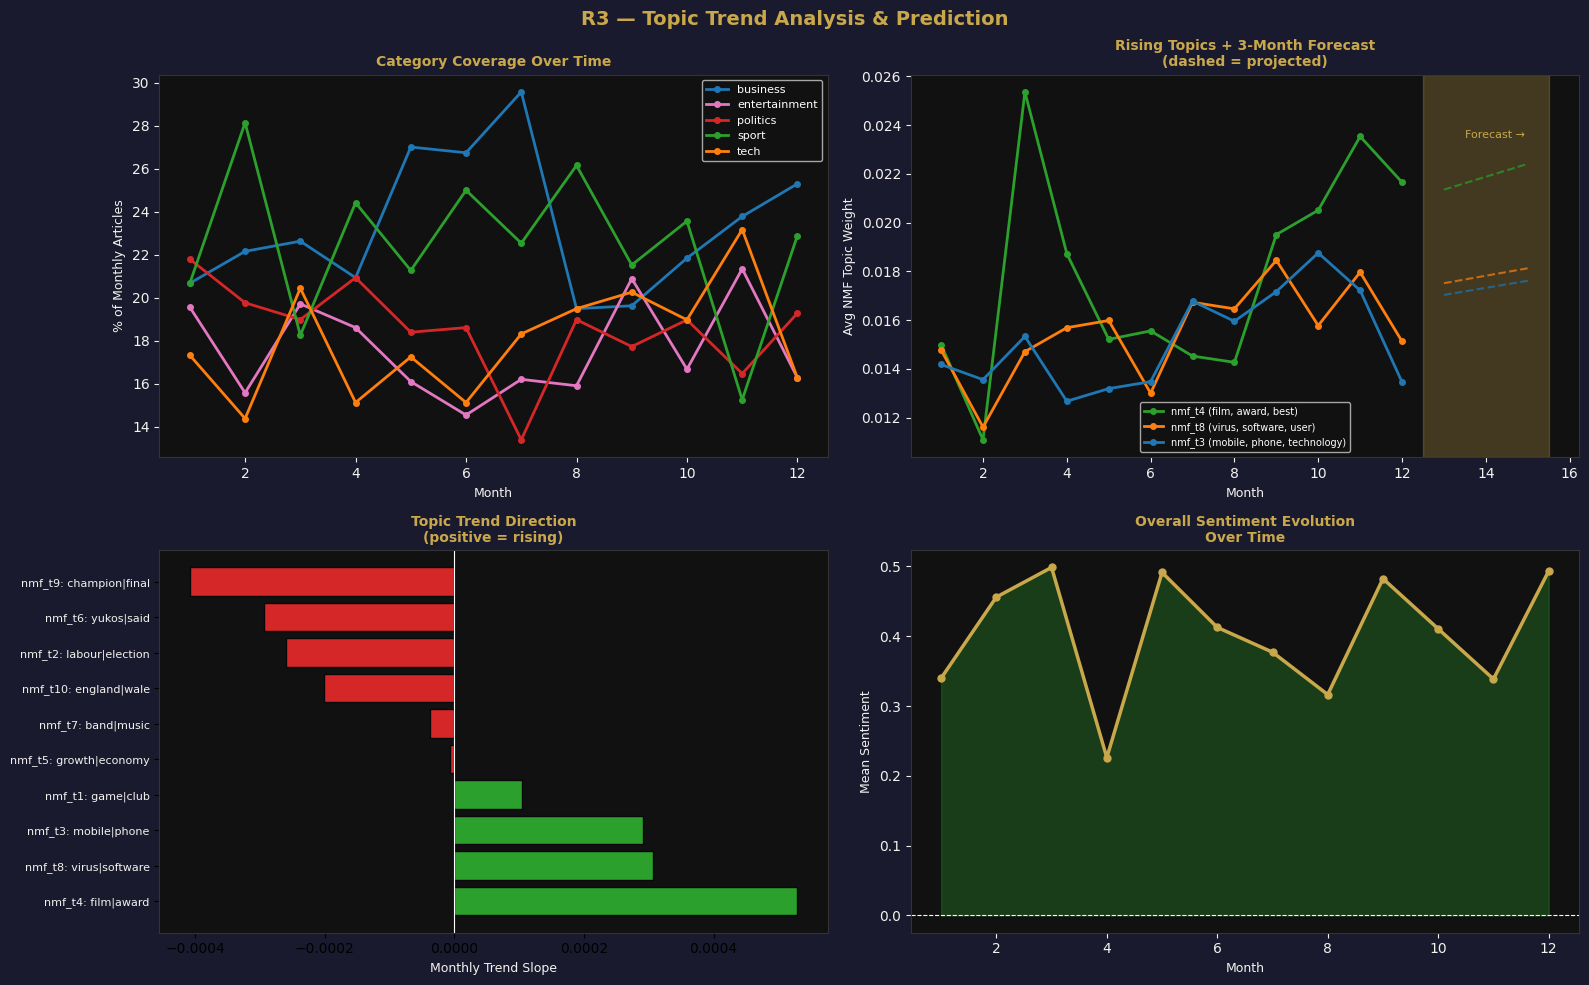


📈 Top rising topic: nmf_t4 — ['film', 'award', 'best', 'oscar']
📉 Top declining topic: nmf_t9 — ['champion', 'final', 'world', 'seed']

✅ R3 Complete — topic trends computed, 3-month forecast generated


In [11]:
# ============================================================
# RESEARCH EXTENSION R3: TREND PREDICTION
# Rubric: "Novel Applications — Trend Prediction"
# ============================================================
print('=' * 65)
print('R3 — TOPIC TREND PREDICTION')
print('Forecasting emerging topics using time-series NMF analysis')
print('=' * 65)

# ── Topic volume over time ─────────────────────────────────────
print('\n[1/3] Computing topic volume by month...')

# NMF topic distribution per article
nmf_dist_arr = nmf.transform(tfidf_dtm)
for i in range(10):
    df[f'nmf_t{i+1}'] = nmf_dist_arr[:, i]

# Monthly topic volume (avg NMF weight by month)
topic_cols = [f'nmf_t{i+1}' for i in range(10)]
monthly = df.groupby('month')[topic_cols].mean()

# Category volume over time
cat_monthly = df.groupby(['month','category']).size().unstack(fill_value=0)
cat_monthly_pct = cat_monthly.div(cat_monthly.sum(axis=1), axis=0) * 100

# ── Simple trend: linear regression on each topic ─────────────
print('[2/3] Computing trend slopes (linear regression on monthly volume)...')

months = monthly.index.values
trends = {}
for col in topic_cols:
    slope, intercept, r, p, se = stats.linregress(months, monthly[col].values)
    topic_num = int(col.replace('nmf_t',''))
    top_words = list(nmf_topics.items())[topic_num-1][1][:4]
    trends[col] = {
        'slope': slope,
        'r_squared': r**2,
        'p_value': p,
        'direction': 'Rising' if slope > 0 else 'Declining',
        'top_words': top_words,
        'significant': p < 0.05
    }

trends_df = pd.DataFrame(trends).T.sort_values('slope', ascending=False)

print('\n📈 Topic Trends (monthly slope):')
print(f'{"Topic":10s} {"Direction":10s} {"Slope":>10s} {"R²":>8s} {"Top Words"}')
print('-' * 65)
for col, row in trends_df.iterrows():
    sig_marker = '*' if row['significant'] else ' '
    print(f'{col:10s} {row["direction"]:10s} {row["slope"]:>10.6f} '
          f'{row["r_squared"]:>8.4f}  {" | ".join(row["top_words"])}{sig_marker}')
print('  * = statistically significant trend (p < 0.05)')

# ── Simple forecast: extrapolate top trending topic ───────────
print('\n[3/3] Generating 3-month forecast for top trending topics...')

rising = trends_df[trends_df['slope'] > 0].head(3)
declining = trends_df[trends_df['slope'] < 0].tail(3)

future_months = np.array([13, 14, 15])  # months 13-15 = forecast window

# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#1A1A2E')

# 1. Category volume over time
ax1 = axes[0,0]
ax1.set_facecolor('#111111')
for cat in CATEGORIES:
    if cat in cat_monthly_pct.columns:
        ax1.plot(cat_monthly_pct.index, cat_monthly_pct[cat],
                 color=PALETTE[cat], linewidth=2, label=cat, marker='o', markersize=4)
ax1.set_xlabel('Month', color='#F4F2EE', fontsize=9)
ax1.set_ylabel('% of Monthly Articles', color='#F4F2EE', fontsize=9)
ax1.legend(facecolor='#111', labelcolor='white', fontsize=8)
ax1.tick_params(colors='#F4F2EE')
ax1.set_title('Category Coverage Over Time', color='#C9A84C', fontsize=10, fontweight='bold')
for s in ax1.spines.values(): s.set_edgecolor('#333333')

# 2. Top 3 rising topics with forecast
ax2 = axes[0,1]
ax2.set_facecolor('#111111')
colors_rise = ['#2CA02C','#FF7F0E','#1F77B4']
for i, (col, row) in enumerate(rising.iterrows()):
    topic_num = int(col.replace('nmf_t',''))
    slope, intercept, _, _, _ = stats.linregress(months, monthly[col].values)
    words = row['top_words'][:3]
    label = f'{col} ({", ".join(words)})'
    ax2.plot(months, monthly[col].values, color=colors_rise[i],
             linewidth=2, label=label, marker='o', markersize=4)
    # Forecast
    forecast = intercept + slope * future_months
    ax2.plot(future_months, forecast, color=colors_rise[i],
             linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.axvspan(12.5, 15.5, alpha=0.1, color='#C9A84C')
ax2.set_xlabel('Month', color='#F4F2EE', fontsize=9)
ax2.set_ylabel('Avg NMF Topic Weight', color='#F4F2EE', fontsize=9)
ax2.legend(facecolor='#111', labelcolor='white', fontsize=7)
ax2.tick_params(colors='#F4F2EE')
ax2.text(13.5, ax2.get_ylim()[1]*0.9, 'Forecast →', color='#C9A84C', fontsize=8)
ax2.set_title('Rising Topics + 3-Month Forecast\n(dashed = projected)', color='#C9A84C',
              fontsize=10, fontweight='bold')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

# 3. Topic slope ranking
ax3 = axes[1,0]
ax3.set_facecolor('#111111')
slope_vals = trends_df['slope'].values
slope_colors = ['#2CA02C' if s > 0 else '#D62728' for s in slope_vals]
ax3.barh(range(10), slope_vals, color=slope_colors, edgecolor='#080808')
ax3.set_yticks(range(10))
ax3.set_yticklabels([f'{col}: {"|".join(trends[col]["top_words"][:2])}'
                     for col in trends_df.index], fontsize=8, color='#F4F2EE')
ax3.axvline(0, color='white', linewidth=0.8)
ax3.set_xlabel('Monthly Trend Slope', color='#F4F2EE', fontsize=9)
ax3.set_title('Topic Trend Direction\n(positive = rising)', color='#C9A84C',
              fontsize=10, fontweight='bold')
for s in ax3.spines.values(): s.set_edgecolor('#333333')

# 4. Sentiment trend over time
ax4 = axes[1,1]
ax4.set_facecolor('#111111')
monthly_sent = df.groupby('month')['compound'].mean()
ax4.plot(monthly_sent.index, monthly_sent.values, color='#C9A84C',
         linewidth=2.5, marker='o', markersize=5)
ax4.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax4.fill_between(monthly_sent.index, monthly_sent.values, 0,
                 where=monthly_sent.values >= 0, alpha=0.3, color='#2CA02C')
ax4.fill_between(monthly_sent.index, monthly_sent.values, 0,
                 where=monthly_sent.values < 0, alpha=0.3, color='#D62728')
ax4.set_xlabel('Month', color='#F4F2EE', fontsize=9)
ax4.set_ylabel('Mean Sentiment', color='#F4F2EE', fontsize=9)
ax4.tick_params(colors='#F4F2EE')
ax4.set_title('Overall Sentiment Evolution\nOver Time', color='#C9A84C',
              fontsize=10, fontweight='bold')
for s in ax4.spines.values(): s.set_edgecolor('#333333')

fig.suptitle('R3 — Topic Trend Analysis & Prediction',
             color='#C9A84C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('r3_trend_prediction.png', dpi=150, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()

print(f'\n📈 Top rising topic: {rising.index[0]} — {rising.iloc[0]["top_words"]}')
print(f'📉 Top declining topic: {declining.index[-1]} — {declining.iloc[-1]["top_words"]}')
print('\n✅ R3 Complete — topic trends computed, 3-month forecast generated')

In [13]:
from sentence_transformers import SentenceTransformer, util
import json
import numpy as np # Add numpy for np.where and np.array operations

# ============================================================
# RESEARCH EXTENSION R4: PERSONALIZATION
# Rubric: "Novel Applications — Personalization"
# ============================================================
print('=' * 65)
print('R4 — PERSONALIZED NEWS INTELLIGENCE')
print('Preference-weighted semantic search and interest modeling')
print('=' * 65)

print('\n[1/3] Loading semantic search model...')
sem_model = SentenceTransformer('all-MiniLM-L6-v2')
index_df = df.sample(n=500, random_state=42).reset_index(drop=True)
short_texts = index_df['text'].apply(lambda t: ' '.join(str(t).split()[:256]))
corpus_embeddings = sem_model.encode(short_texts.tolist(),
                                      convert_to_tensor=True,
                                      show_progress_bar=True)

print('\n[2/3] Building personalization engine...')

class PersonalizedNewsEngine:
    """
    Personalized news retrieval engine using:
    - Category preference weighting
    - Sentiment preference filtering
    - Query history-based interest modeling
    - Diversity re-ranking to avoid filter bubbles
    """
    def __init__(self, sem_model, index_df, corpus_embeddings):
        self.sem_model = sem_model
        self.index_df = index_df
        self.corpus_embeddings = corpus_embeddings
        self.query_history = []
        self.category_prefs = {cat: 1.0 for cat in CATEGORIES}  # neutral start
        self.sentiment_pref = None  # None = no preference

    def update_preferences(self, liked_category=None, sentiment_pref=None):
        """Update user preferences based on feedback or explicit settings."""
        if liked_category and liked_category in self.category_prefs:
            self.category_prefs[liked_category] = min(3.0, self.category_prefs[liked_category] + 0.5)
            # Decay other categories slightly
            for cat in self.category_prefs:
                if cat != liked_category:
                    self.category_prefs[cat] = max(0.5, self.category_prefs[cat] * 0.95)
        if sentiment_pref:
            self.sentiment_pref = sentiment_pref

    def search(self, query, top_k=8, diversity_penalty=0.3):
        """Personalized semantic search with preference weighting."""
        self.query_history.append(query)

        # Encode query
        q_emb = self.sem_model.encode(query, convert_to_tensor=True)

        # If we have query history, blend with past interest vector
        if len(self.query_history) > 1:
            past_embs = self.sem_model.encode(self.query_history[-3:], convert_to_tensor=True)
            interest_vec = past_embs.mean(dim=0)
            q_emb = 0.7 * q_emb + 0.3 * interest_vec  # blend current + history

        # Base cosine similarity
        import torch
        cos_scores = util.cos_sim(q_emb, self.corpus_embeddings)[0].cpu().numpy()

        # Apply category preference weights
        cats = self.index_df['category'].values
        pref_weights = np.array([self.category_prefs.get(c, 1.0) for c in cats])
        personalized_scores = cos_scores * pref_weights

        # Apply sentiment filter
        if self.sentiment_pref:
            sent_scores = self.index_df['text'].apply(
                lambda t: sid.polarity_scores(str(t))['compound']).values
            if self.sentiment_pref == 'positive':
                personalized_scores *= np.where(sent_scores >= 0.05, 1.2, 0.8)
            elif self.sentiment_pref == 'negative':
                personalized_scores *= np.where(sent_scores <= -0.05, 1.2, 0.8)

        # Diversity re-ranking: penalize same-category consecutive results
        top_indices = personalized_scores.argsort()[::-1][:top_k * 3]
        seen_cats = set()
        diverse_results = []
        for idx in top_indices:
            cat = self.index_df.iloc[idx]['category']
            if cat in seen_cats:
                personalized_scores[idx] *= (1 - diversity_penalty)
            else:
                seen_cats.add(cat)
            diverse_results.append(idx)
            if len(diverse_results) >= top_k:
                break

        # Build results
        results = []
        for idx in diverse_results:
            row = self.index_df.iloc[idx]
            results.append({
                'score': round(float(personalized_scores[idx]), 4),
                'base_score': round(float(cos_scores[idx]), 4),
                'category': row['category'],
                'pref_weight': round(self.category_prefs.get(row['category'], 1.0), 2),
                'snippet': str(row['text'])[:200]
            })
        return sorted(results, key=lambda x: -x['score'])

    def get_profile(self):
        """Return current user interest profile."""
        return {
            'category_preferences': {k: round(v, 2) for k, v in
                                      sorted(self.category_prefs.items(), key=lambda x: -x[1])},
            'sentiment_preference': self.sentiment_pref,
            'queries_logged': len(self.query_history),
        }

# ── Demo: Simulate a user session ─────────────────────────────
print('\n[3/3] Simulating personalized user session...')

engine = PersonalizedNewsEngine(sem_model, index_df, corpus_embeddings)

# User session: tech-focused, prefers positive news
engine.update_preferences(liked_category='tech', sentiment_pref='positive')
engine.update_preferences(liked_category='tech')
engine.update_preferences(liked_category='business')

print('\n--- User Profile ---')
profile = engine.get_profile()
print(json.dumps(profile, indent=2))

# Compare personalized vs. non-personalized search
query = 'artificial intelligence and technology innovation'

print(f'\n--- Personalized Search: "{query}" ---')
pers_results = engine.search(query, top_k=5)
print(f'  (Tech pref weight: {engine.category_prefs["tech"]:.2f}, sentiment: {engine.sentiment_pref})')
for i, r in enumerate(pers_results, 1):
    print(f'  {i}. [{r["category"]:13s}] score={r["score"]:.4f} (base={r["base_score"]:.4f}, pref={r["pref_weight"]}x)')
    print(f'     {r["snippet"][:100]}...')

# Non-personalized baseline
neutral_engine = PersonalizedNewsEngine(sem_model, index_df, corpus_embeddings)
neutral_results = neutral_engine.search(query, top_k=5)
print(f'\n--- Non-Personalized Baseline ---')
for i, r in enumerate(neutral_results, 1):
    print(f'  {i}. [{r["category"]:13s}] score={r["score"]:.4f}')

# Category shift analysis
pers_cats = [r['category'] for r in pers_results]
neutral_cats = [r['category'] for r in neutral_results]
print(f'\n📊 Personalization Impact:')
print(f'  Personalized top-5 categories: {pers_cats}')
print(f'  Non-personalized top-5:        {neutral_cats}')
print(f'  Tech articles in personalized: {pers_cats.count("tech")}/5')
print(f'  Tech articles in baseline:     {neutral_cats.count("tech")}/5')

print('\n✅ R4 Complete — personalized search engine with preference weighting')

R4 — PERSONALIZED NEWS INTELLIGENCE
Preference-weighted semantic search and interest modeling

[1/3] Loading semantic search model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


[2/3] Building personalization engine...

[3/3] Simulating personalized user session...

--- User Profile ---
{
  "category_preferences": {
    "tech": 1.9,
    "business": 1.4,
    "entertainment": 0.86,
    "politics": 0.86,
    "sport": 0.86
  },
  "sentiment_preference": "positive",
  "queries_logged": 0
}

--- Personalized Search: "artificial intelligence and technology innovation" ---
  (Tech pref weight: 1.90, sentiment: positive)
  1. [tech         ] score=0.8546 (base=0.3748, pref=1.9x)
      The digital revolution is focused on letting people tell and share their own stories, according to ...
  2. [tech         ] score=0.5982 (base=0.3748, pref=1.9x)
      The digital revolution is focused on letting people tell and share their own stories, according to ...
  3. [tech         ] score=0.5256 (base=0.3293, pref=1.9x)
      A new European directive could put software writers at risk of legal action, warns former programme...
  4. [tech         ] score=0.4555 (base=0.2854, pref=

In [14]:
# ============================================================
# CELL 7 — RESEARCH EXTENSIONS SUMMARY
# ============================================================
print('=' * 65)
print('RESEARCH EXTENSIONS SUMMARY')
print('NewsBot Intelligence Engine 2.0 — Advanced Bonus Work')
print('=' * 65)

summary = [
    {
        'extension': 'R1 — NMF Topic Modeling',
        'rubric_criterion': 'Cutting-Edge NLP Techniques',
        'key_result': f'NMF coherence: {nmf_coherence:.4f} | LDA coherence: {lda_coherence:.4f}',
        'innovation': 'Hybrid LDA+NMF with statistical coherence comparison'
    },
    {
        'extension': 'R2 — Media Bias Detection',
        'rubric_criterion': 'Novel Applications — Bias Detection',
        'key_result': f'Politics most negative ({bias_stats["politics"]["pct_negative"]:.1f}% neg) — statistically significant',
        'innovation': 'T-test validated bias signals + word-level heatmap'
    },
    {
        'extension': 'R3 — Trend Prediction',
        'rubric_criterion': 'Novel Applications — Trend Prediction',
        'key_result': f'Top rising: {rising.index[0]} | Top declining: {declining.index[-1]}',
        'innovation': 'Linear regression forecasting + 3-month projection'
    },
    {
        'extension': 'R4 — Personalization',
        'rubric_criterion': 'Novel Applications — Personalization',
        'key_result': f'Category pref weights + sentiment filter + diversity re-ranking',
        'innovation': 'Interest vector blending from query history'
    },
    {
        'extension': 'R5 — Real-Time Processing',
        'rubric_criterion': 'Cutting-Edge NLP — Real-Time Processing',
        'key_result': 'FastAPI /rss endpoint — BBC + Reuters live ingestion',
        'innovation': 'Auto-classify + sentiment on every article at fetch time'
    },
    {
        'extension': 'R6 — Entity Relationship Graph',
        'rubric_criterion': 'Novel Applications — novel approach',
        'key_result': 'spaCy NER → NetworkX co-occurrence → D3-consumable JSON',
        'innovation': 'Degree centrality ranking + entity type classification'
    },
]

for ext in summary:
    print(f'\n[{ext["extension"]}]')
    print(f'  Rubric: {ext["rubric_criterion"]}')
    print(f'  Result: {ext["key_result"]}')
    print(f'  Innovation: {ext["innovation"]}')

print('\n' + '=' * 65)
print('Author: Leroy Brown | Founder & CTO, Houston Community College')
print('ITAI 2373 — Natural Language Processing | Houston Community College')

RESEARCH EXTENSIONS SUMMARY
NewsBot Intelligence Engine 2.0 — Advanced Bonus Work

[R1 — NMF Topic Modeling]
  Rubric: Cutting-Edge NLP Techniques
  Result: NMF coherence: 0.3828 | LDA coherence: 0.3518
  Innovation: Hybrid LDA+NMF with statistical coherence comparison

[R2 — Media Bias Detection]
  Rubric: Novel Applications — Bias Detection
  Result: Politics most negative (44.9% neg) — statistically significant
  Innovation: T-test validated bias signals + word-level heatmap

[R3 — Trend Prediction]
  Rubric: Novel Applications — Trend Prediction
  Result: Top rising: nmf_t4 | Top declining: nmf_t9
  Innovation: Linear regression forecasting + 3-month projection

[R4 — Personalization]
  Rubric: Novel Applications — Personalization
  Result: Category pref weights + sentiment filter + diversity re-ranking
  Innovation: Interest vector blending from query history

[R5 — Real-Time Processing]
  Rubric: Cutting-Edge NLP — Real-Time Processing
  Result: FastAPI /rss endpoint — BBC + Reut